### Moving to aggregation methods and global assignment with splink

In [1]:
import pandas as pd
from splink import Linker, DuckDBAPI
import pyarrow as pa
import pyarrow.parquet as pq
import os

import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))  # Add parent directory

df1_path = os.path.join("..", "..", "output_data", "smallestest_dataset_a.parquet")
df2_path = os.path.join("..", "..", "output_data", "smallestest_dataset_b.parquet")


df1 = pd.read_parquet(df1_path)
df2 = pd.read_parquet(df2_path)



In [11]:
df1

,global_entity_id,local_source_id,categorical,numerical_noisy,datetime_noisy,latent_event_id
0,100073,DF1_100073,CAT_1,722.39,2025-12-31 22:01:11.513018628,OVER_1
1,100073,DF1_100073,CAT_5,655.69,2026-01-01 01:44:35.403874141,OVER_0
2,100076,DF1_100076,CAT_2,NaN,2026-01-01 02:24:44.802460282,UNI_A_126
3,100081,DF1_100081,CAT_1,350.00,2026-01-01 05:42:28.935687291,UNI_A_127
4,100000,DF1_100000,CAT_6,1145.84,2026-01-01 05:57:50.104955089,UNI_A_128
...,...,...,...,...,...,...
1327,100029,DF1_100029,CAT_1,147.28,2026-05-31 19:21:36.010971863,UNI_A_1327
1328,100003,DF1_100003,CAT_3,1028.96,2026-05-31 21:41:44.332548011,UNI_A_1328
1329,100020,DF1_100020,CAT_1,537.59,2026-05-31 23:32:16.393217545,UNI_A_1329
1330,100001,DF1_100001,CAT_7,380.71,2026-06-01 05:38:10.221252267,UNI_A_1330


In [2]:
# Get predictions
predicts_file_path = "../local_predicts/smallestest_predictions.parquet"
predicts_pd = pd.read_parquet(predicts_file_path)

predicts_pd

,match_weight,match_probability,source_dataset_l,source_dataset_r,latent_event_id_l,latent_event_id_r,numerical_noisy_l,numerical_noisy_r,gamma_numerical_noisy,bf_numerical_noisy,...,bf_categorical,datetime_noisy_l,datetime_noisy_r,gamma_datetime_noisy,bf_datetime_noisy,local_source_id_l,local_source_id_r,global_entity_id_l,global_entity_id_r,match_key
0,-31.300995,3.779738e-10,__splink__input_table_0,__splink__input_table_1,UNI_A_897,UNIQ_B_1925,427.1,1253.26,1,0.016459,...,0.002357,2026-04-07,2026-03-01,0,0.054437,DF1_100005,DF2_100082,100005,100082,4
1,-31.300995,3.779738e-10,__splink__input_table_0,__splink__input_table_1,UNI_A_897,UNIQ_B_1926,427.1,246.82,1,0.016459,...,0.002357,2026-04-07,2026-03-01,0,0.054437,DF1_100005,DF2_100011,100005,100011,4
2,-31.680401,2.905689e-10,__splink__input_table_0,__splink__input_table_1,UNI_A_897,UNIQ_B_1927,427.1,1592.38,0,0.012653,...,0.002357,2026-04-07,2026-03-02,0,0.054437,DF1_100005,DF2_100058,100005,100058,4
3,-31.300995,3.779738e-10,__splink__input_table_0,__splink__input_table_1,UNI_A_897,UNIQ_B_1931,427.1,207.88,1,0.016459,...,0.002357,2026-04-07,2026-03-02,0,0.054437,DF1_100005,DF2_100048,100005,100048,4
4,-29.889032,1.005784e-09,__splink__input_table_0,__splink__input_table_1,UNI_A_897,UNIQ_B_1932,427.1,574.55,2,0.043798,...,0.002357,2026-04-07,2026-03-02,0,0.054437,DF1_100005,DF2_100014,100005,100014,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384917,-31.680401,2.905689e-10,__splink__input_table_0,__splink__input_table_1,UNI_A_545,UNIQ_B_2202,220.1,1185.33,0,0.012653,...,0.002357,2026-02-23,2026-03-30,0,0.054437,DF1_100084,DF2_100047,100084,100047,3
1384918,-29.889032,1.005784e-09,__splink__input_table_0,__splink__input_table_1,UNI_A_545,UNIQ_B_2203,220.1,323.01,2,0.043798,...,0.002357,2026-02-23,2026-03-30,0,0.054437,DF1_100084,DF2_100013,100084,100013,3
1384919,-31.680401,2.905689e-10,__splink__input_table_0,__splink__input_table_1,UNI_A_545,UNIQ_B_2204,220.1,965.97,0,0.012653,...,0.002357,2026-02-23,2026-03-31,0,0.054437,DF1_100084,DF2_100041,100084,100041,3
1384920,-31.680401,2.905689e-10,__splink__input_table_0,__splink__input_table_1,UNI_A_545,OVER_84,220.1,885.45,0,0.012653,...,0.002357,2026-02-23,2026-03-31,0,0.054437,DF1_100084,DF1_100051,100084,100051,3


In [12]:
# We start with a naive approach - the idea is just to transition this set of match_weights 
# from 2d per global entity pair into a single value via some sort of aggregation
# Our aggregation must thus follow this format:
# val: int = agg_func(e1_e2_match_weights)

# A simple way could be doing something like taking expected value of probs (or essentially a weighted sum of the probs)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

left_counts  = df1["local_source_id"].value_counts()   # Series: id → frequency in df1
right_counts = df2["local_source_id"].value_counts()   # Series: id → frequency in df2

agg_df = (
    predicts_pd[
        ['local_source_id_l', 'local_source_id_r','match_probability']
    ]
    .groupby(['local_source_id_l', 'local_source_id_r'], as_index=False)
    .agg({'match_probability': sum})
)

agg_df

/tmp/ipykernel_2556560/3193128806.py:20: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'match_probability': sum})


,local_source_id_l,local_source_id_r,match_probability
0,DF1_100000,DF1_100039,0.008171
1,DF1_100000,DF1_100051,0.032486
2,DF1_100000,DF1_100073,0.021682
3,DF1_100000,DF1_100075,0.015593
4,DF1_100000,DF1_100087,0.004548
...,...,...,...
2495,DF1_100094,DF2_100083,0.026606
2496,DF1_100094,DF2_100085,0.049700
2497,DF1_100094,DF2_100090,0.170208
2498,DF1_100094,DF2_100091,0.978706


In [17]:
unique_l = left_counts.index
unique_r = right_counts.index

# Cartesian product of the observed ids (still a DataFrame)
pair_keys = pd.MultiIndex.from_product(
    [unique_l, unique_r],
    names=["local_source_id_l", "local_source_id_r"]
).to_frame(index=False)

# Attach the left and right counts
pair_keys = pair_keys.merge(
    left_counts.rename("left_count"),
    left_on="local_source_id_l",
    right_index=True,
    how="left"
).merge(
    right_counts.rename("right_count"),
    left_on="local_source_id_r",
    right_index=True,
    how="left"
)

# Pair‑specific denominator = left_count × right_count
pair_keys["pair_size"] = pair_keys["left_count"] * pair_keys["right_count"]

# -------------------------------------------------
# 4️⃣  Join the aggregated probabilities to the pair‑specific sizes
# -------------------------------------------------
norm_df = pair_keys.merge(
    agg_df,
    on=["local_source_id_l", "local_source_id_r"],
    how="left"               # keep all pairs; missing probabilities become NaN
)

norm_df["norm_match_prob"] = norm_df["match_probability"] / norm_df["pair_size"]

norm_df

,local_source_id_l,local_source_id_r,left_count,right_count,pair_size,match_probability,norm_match_prob
0,DF1_100005,DF2_100048,50,55,2750,0.259610,9.440362e-05
1,DF1_100005,DF2_100067,50,52,2600,0.051902,1.996231e-05
2,DF1_100005,DF2_100066,50,52,2600,1.134498,4.363455e-04
3,DF1_100005,DF2_100036,50,48,2400,0.106126,4.421899e-05
4,DF1_100005,DF2_100043,50,47,2350,0.127682,5.433258e-05
...,...,...,...,...,...,...,...
2495,DF1_100007,DF1_100073,4,17,68,0.005524,8.123865e-05
2496,DF1_100007,DF2_100049,4,16,64,0.000384,6.005037e-06
2497,DF1_100007,DF2_100060,4,13,52,0.000111,2.135242e-06
2498,DF1_100007,DF2_100035,4,4,16,0.000012,7.201803e-07


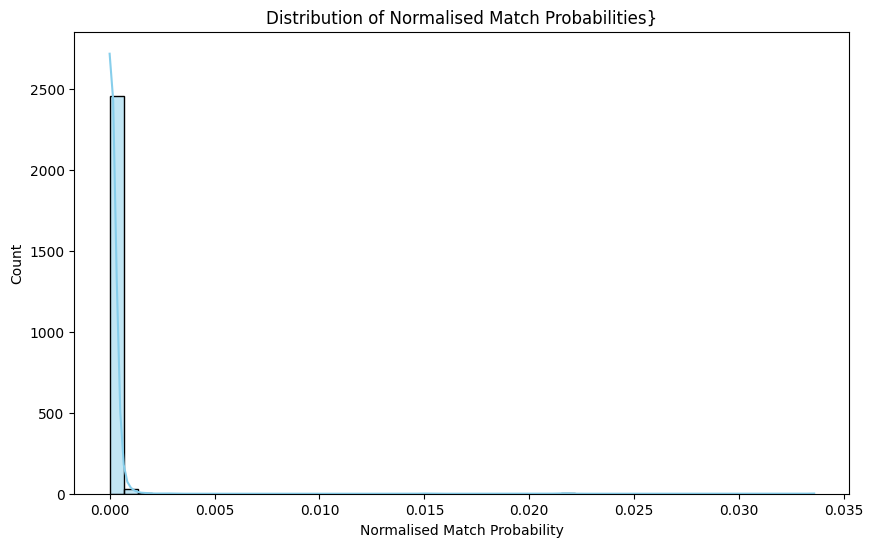

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# kde=True adds a smooth distribution line over the bars
sns.histplot(data=norm_df, x='norm_match_prob', bins=50, kde=True, color='skyblue')

plt.title('Distribution of Normalised Match Probabilities}')
plt.xlabel('Normalised Match Probability')
plt.ylabel('Count')
plt.show()


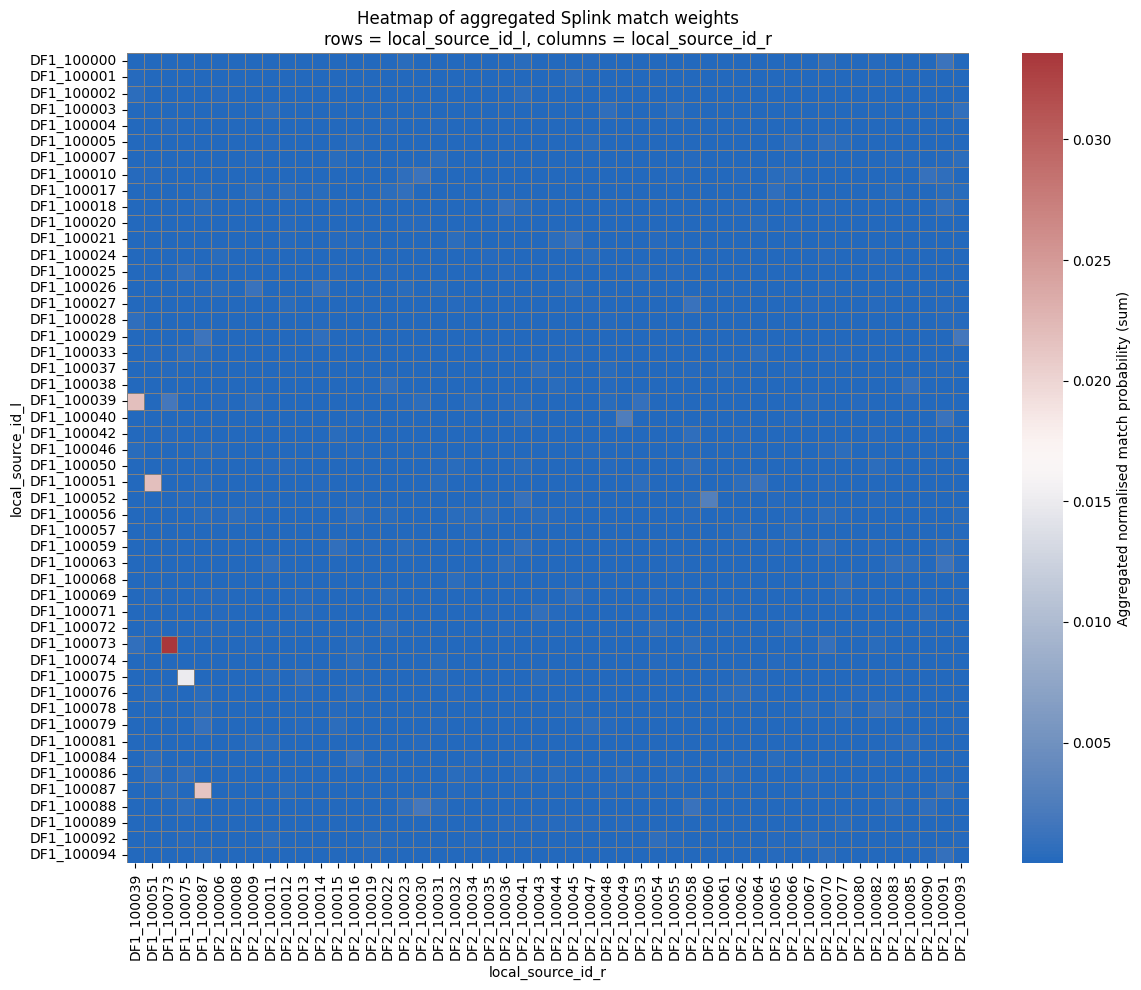

In [19]:
mat = norm_df.pivot(
    index = 'local_source_id_l',
    columns = 'local_source_id_r',
    values = 'norm_match_prob'
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    mat,
    cmap='vlag',           # diverging colormap; change if you prefer another
    mask=mat.isna(),       # hide missing cells (pairs with no observations)
    linewidths=.5,
    linecolor='gray',
    cbar_kws={'label': 'Aggregated normalised match probability (sum)'}
)
plt.title('Heatmap of aggregated Splink match weights\n'
          'rows = local_source_id_l, columns = local_source_id_r')
plt.xlabel('local_source_id_r')
plt.ylabel('local_source_id_l')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2556560/561077175.py:7: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'match_weight': sum})


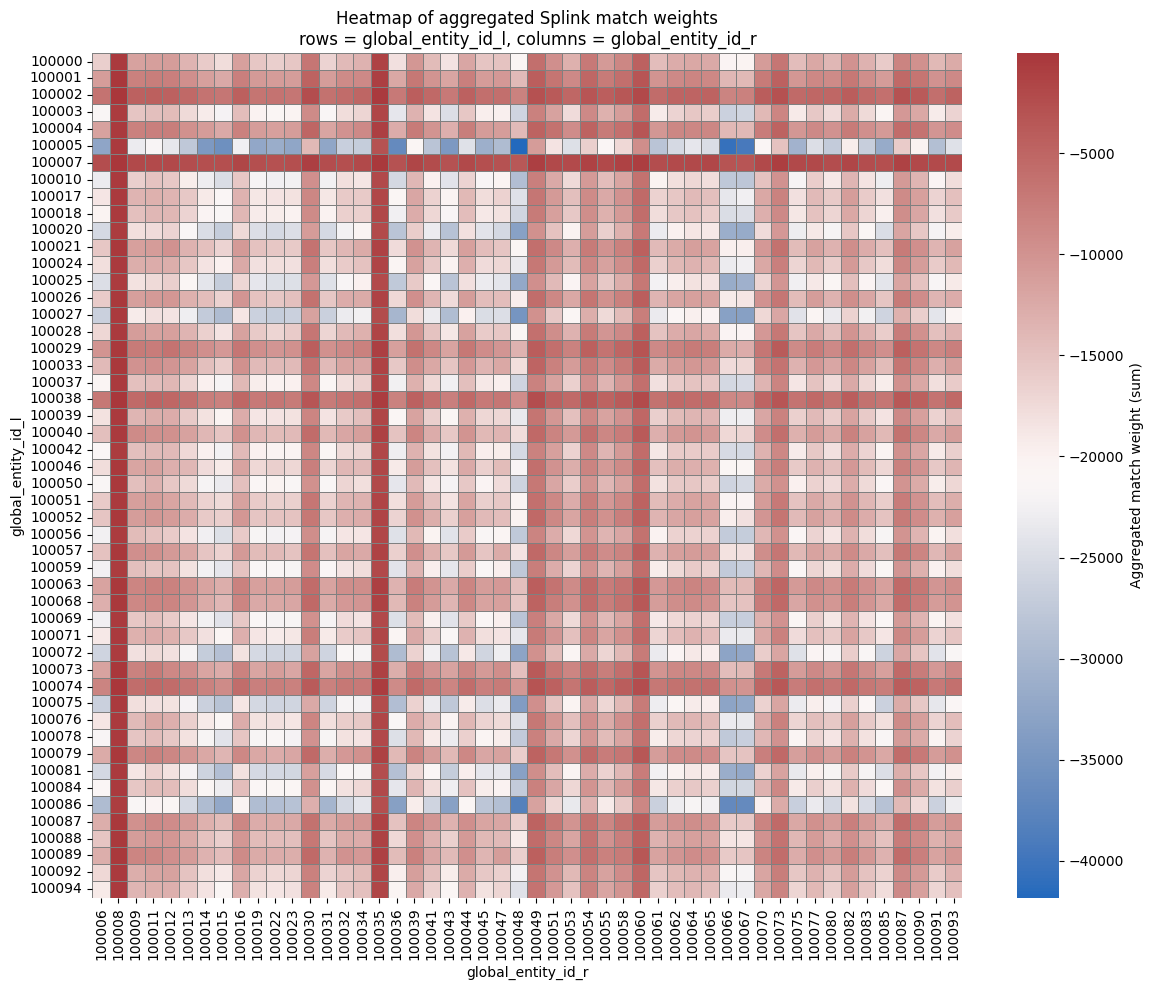

In [10]:
# for global_entity_id
global_agg_df = (
    predicts_pd[
        ['global_entity_id_l', 'global_entity_id_r','match_weight']
    ]
    .groupby(['global_entity_id_l', 'global_entity_id_r'], as_index=False)
    .agg({'match_weight': sum})
)

global_mat = global_agg_df.pivot(
    index = 'global_entity_id_l',
    columns = 'global_entity_id_r',
    values = 'match_weight'
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    global_mat,
    cmap='vlag',           # diverging colormap; change if you prefer another
    mask=global_mat.isna(),       # hide missing cells (pairs with no observations)
    linewidths=.5,
    linecolor='gray',
    cbar_kws={'label': 'Aggregated match weight (sum)'}
)
plt.title('Heatmap of aggregated Splink match weights\n'
          'rows = global_entity_id_l, columns = global_entity_id_r')
plt.xlabel('global_entity_id_r')
plt.ylabel('global_entity_id_l')
plt.tight_layout()
plt.show()
